# Cell 1 — Feature C — Thumbnail Visual Grouping
## Image Preprocessing and Exploratory Data Analysis

### Notebook Purpose

This notebook prepares Amazon product thumbnail images for the Feature C visual grouping task.

The objective of Feature C is to group product images into visually similar groups using unsupervised machine learning, without using website category labels or other product metadata as clustering inputs.

This notebook covers:

1. Loading the product dataset.
2. Validating ASIN and image URL availability.
3. Creating a unique product-image manifest.
4. Downloading product images.
5. Saving images using ASIN-based filenames.
6. Detecting invalid or corrupted images.
7. Exploring image dimensions and formats.
8. Visually inspecting representative product thumbnails.
9. Creating a clean image manifest for the model development notebook.

### Image Identity Strategy

Each downloaded image will be associated with its Amazon Standard Identification Number (ASIN).

Images will be stored using the following naming convention:

`{ASIN}.jpg`

Example:

`B0XXXXXXXXXX.jpg`

A manifest file will preserve the relationship between:

- ASIN
- Original image URL
- Local image path
- Download status
- Image validation status

### Visual-Only Grouping Principle

The following information will **not** be used as input for visual clustering:

- Search keywords
- Product titles
- Product descriptions
- Brand
- Price
- Price tier
- Website category labels

These fields may only be used later for optional post-clustering sanity checks.

### Expected Output

The primary output of this notebook will be a validated image manifest containing successfully downloaded and usable product images.

This manifest will serve as the input to:

`02_model_development.ipynb`

In [1]:
# =============================================================================
# CELL 2 — IMPORTS AND CONFIGURATION
# =============================================================================

import io
import json
import random
import time
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import requests

from PIL import Image, UnidentifiedImageError

import matplotlib.pyplot as plt

from tqdm.auto import tqdm


# ---------------------------------------------------------------------------
# WARNING CONFIGURATION
# ---------------------------------------------------------------------------

warnings.filterwarnings("ignore")


# ---------------------------------------------------------------------------
# ENVIRONMENT
# ---------------------------------------------------------------------------

# Options:
# "colab" -> Google Colab
# "local" -> VS Code / Local Jupyter
ENVIRONMENT = "colab"


# ---------------------------------------------------------------------------
# PROJECT ROOT
# ---------------------------------------------------------------------------

if ENVIRONMENT == "colab":
    PROJECT_ROOT = Path("/content")

elif ENVIRONMENT == "local":
    PROJECT_ROOT = Path.cwd().parent.parent.parent

else:
    raise ValueError(
        "ENVIRONMENT must be either 'colab' or 'local'."
    )


# ---------------------------------------------------------------------------
# PROJECT DIRECTORIES
# ---------------------------------------------------------------------------

DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

IMAGE_DIR = DATA_DIR / "images"

FEATURE_C_DATA_DIR = PROCESSED_DATA_DIR / "feature_c"

MANIFEST_DIR = FEATURE_C_DATA_DIR / "manifests"


# ---------------------------------------------------------------------------
# CREATE REQUIRED DIRECTORIES
# ---------------------------------------------------------------------------

for directory in [
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    IMAGE_DIR,
    FEATURE_C_DATA_DIR,
    MANIFEST_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ---------------------------------------------------------------------------
# REPRODUCIBILITY
# ---------------------------------------------------------------------------

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


# ---------------------------------------------------------------------------
# IMAGE DOWNLOAD CONFIGURATION
# ---------------------------------------------------------------------------

REQUEST_TIMEOUT = 20

MAX_RETRIES = 3

RETRY_DELAY = 1

TARGET_IMAGE_FORMAT = "JPEG"


# ---------------------------------------------------------------------------
# EDA CONFIGURATION
# ---------------------------------------------------------------------------

RANDOM_SAMPLE_SIZE = 12


# ---------------------------------------------------------------------------
# DISPLAY CONFIGURATION
# ---------------------------------------------------------------------------

print("=" * 80)
print("FEATURE C — IMAGE PREPROCESSING & EDA")
print("=" * 80)

print(f"Environment          : {ENVIRONMENT}")
print(f"Project Root         : {PROJECT_ROOT}")
print(f"Raw Data Directory   : {RAW_DATA_DIR}")
print(f"Processed Data Dir   : {PROCESSED_DATA_DIR}")
print(f"Image Directory      : {IMAGE_DIR}")
print(f"Feature C Data Dir   : {FEATURE_C_DATA_DIR}")
print(f"Random State         : {RANDOM_STATE}")

FEATURE C — IMAGE PREPROCESSING & EDA
Environment          : colab
Project Root         : /content
Raw Data Directory   : /content/data/raw
Processed Data Dir   : /content/data/processed
Image Directory      : /content/data/images
Feature C Data Dir   : /content/data/processed/feature_c
Random State         : 42


In [2]:
# =============================================================================
# CELL 3A — LOAD SOURCE DATASET (GOOGLE COLAB)
# =============================================================================

from google.colab import files
import io

print("Please upload the processed product dataset (cleaned_products.csv) CSV file.")

uploaded = files.upload()

if not uploaded:
    raise ValueError("No file was uploaded.")

uploaded_filename = next(iter(uploaded))

print(f"\nUploaded file: {uploaded_filename}")


# ---------------------------------------------------------------------------
# Load dataset
# ---------------------------------------------------------------------------

DATASET_PATH = RAW_DATA_DIR / uploaded_filename

with open(DATASET_PATH, "wb") as f:
    f.write(uploaded[uploaded_filename])


df = pd.read_csv(DATASET_PATH)



# ---------------------------------------------------------------------------
# Basic dataset inspection
# ---------------------------------------------------------------------------

print("=" * 80)
print("SOURCE DATASET LOADED SUCCESSFULLY")
print("=" * 80)

print(f"Dataset path : {DATASET_PATH}")
print(f"Dataset shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nRequired Feature C columns:")
print(f"ASIN column available : {'asin' in df.columns}")
print(f"Image column available: {'image' in df.columns}")

display(df.head())

Please upload the processed product dataset (cleaned_products.csv) CSV file.


Saving cleaned_products.csv to cleaned_products.csv

Uploaded file: cleaned_products.csv
SOURCE DATASET LOADED SUCCESSFULLY
Dataset path : /content/data/raw/cleaned_products.csv
Dataset shape: (946, 17)

Columns:
['product_number', 'asin', 'search_keyword', 'title', 'url', 'price', 'description', 'description_imputed', 'brand', 'image', 'review_count', 'average_rating', 'video_url', 'reviews', 'review_number_collected', 'title_length', 'description_length']

Required Feature C columns:
ASIN column available : True
Image column available: True


,product_number,asin,search_keyword,title,url,price,description,description_imputed,brand,image,review_count,average_rating,video_url,reviews,review_number_collected,title_length,description_length
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",https://www.amazon.com/Wireless-Sports-Earbuds...,25.99,About this item\r\nSecure Fit for High-Intensi...,False,Csasan,https://m.media-amazon.com/images/I/613tyoH+sm...,9662,4.4,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Needsmorenails"", ""star_rat...",8,196,2969
1,2,B0GFF3RCCL,wireless earbuds,TALIX T30 Noise Cancelling Earbuds with Phone ...,https://www.amazon.com/TALIX-Cancelling-Blueto...,25.99,About this item\r\n【Punchy Bass】 Featuring 10m...,False,TALIX,https://m.media-amazon.com/images/I/511IigIBpo...,67,4.3,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Michelle"", ""star_rating"": ...",8,149,1544
2,3,B0HBWW3958,wireless earbuds,"Wireless Earbuds, Bluetooth 5.3 Headphones HiF...",https://www.amazon.com/Fhumsh-Bluetooth-Headph...,19.98,About this item\r\nSmart LED Display & 50H Spo...,False,Brand: Fhumsh,https://m.media-amazon.com/images/I/61D5ZCSIym...,196,5.0,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Mary Santana"", ""star_ratin...",8,184,2127
3,4,B0H9LHWBDK,wireless earbuds,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",https://www.amazon.com/Bluetooth-Headphones-Ca...,18.99,About this item\r\nLED Power Display and 50H P...,False,Brand: XIAOWTEK,https://m.media-amazon.com/images/I/61odQgshCW...,782,4.6,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""diamela"", ""star_rating"": 5...",8,195,2406
4,5,B0H7R1LD7B,wireless earbuds,"HAOYUYAN Wireless Earbuds, Sports Bluetooth He...",https://www.amazon.com/HAOYUYAN-Bluetooth-Head...,23.98,About this item\r\n【Sports Comfort & IPX7 Wate...,False,HAOYUYAN,https://m.media-amazon.com/images/I/71cmAChhQK...,371,4.6,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Shigo"", ""star_rating"": 5.0...",5,181,2501


In [3]:
"""# =============================================================================
# CELL 3B — LOAD SOURCE DATASET (LOCAL / VS CODE)
# =============================================================================

# Update this filename to match your actual dataset
DATASET_PATH = RAW_DATA_DIR / "amazon_products.csv"


if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_PATH}\n\n"
        "Please update DATASET_PATH with the correct filename."
    )


# ---------------------------------------------------------------------------
# Load dataset
# ---------------------------------------------------------------------------

df = pd.read_csv(DATASET_PATH)


# ---------------------------------------------------------------------------
# Basic validation
# ---------------------------------------------------------------------------

print("=" * 80)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 80)

print(f"Dataset path : {DATASET_PATH}")
print(f"Dataset shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

display(df.head())"""

'# =============================================================================\n# CELL 3B — LOAD SOURCE DATASET (LOCAL / VS CODE)\n# =============================================================================\n\n# Update this filename to match your actual dataset\nDATASET_PATH = RAW_DATA_DIR / "amazon_products.csv"\n\n\nif not DATASET_PATH.exists():\n    raise FileNotFoundError(\n        f"Dataset not found:\n{DATASET_PATH}\n\n"\n        "Please update DATASET_PATH with the correct filename."\n    )\n\n\n# ---------------------------------------------------------------------------\n# Load dataset\n# ---------------------------------------------------------------------------\n\ndf = pd.read_csv(DATASET_PATH)\n\n\n# ---------------------------------------------------------------------------\n# Basic validation\n# ---------------------------------------------------------------------------\n\nprint("=" * 80)\nprint("DATASET LOADED SUCCESSFULLY")\nprint("=" * 80)\n\nprint(f"Dataset path

In [4]:
# =============================================================================
# CELL 4 — VALIDATE ASIN AND IMAGE URL INTEGRITY
# =============================================================================

# ---------------------------------------------------------------------------
# Required columns
# ---------------------------------------------------------------------------

REQUIRED_COLUMNS = ["asin", "image"]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns missing: {missing_columns}"
    )


# ---------------------------------------------------------------------------
# Basic missing value checks
# ---------------------------------------------------------------------------

total_rows = len(df)

missing_asin = df["asin"].isna().sum()

missing_image = (
    df["image"].isna().sum()
    + df["image"].astype(str).str.strip().eq("").sum()
)


# ---------------------------------------------------------------------------
# Duplicate checks
# ---------------------------------------------------------------------------

duplicate_asin_rows = df["asin"].duplicated().sum()

duplicate_image_rows = (
    df["image"]
    .dropna()
    .duplicated()
    .sum()
)


# ---------------------------------------------------------------------------
# ASIN → Image URL consistency
# ---------------------------------------------------------------------------

asin_image_counts = (
    df.dropna(subset=["asin", "image"])
    .groupby("asin")["image"]
    .nunique()
)

asins_with_multiple_images = asin_image_counts[
    asin_image_counts > 1
]


# ---------------------------------------------------------------------------
# Unique valid ASIN-image pairs
# ---------------------------------------------------------------------------

valid_pairs = (
    df[["asin", "image"]]
    .dropna()
    .copy()
)

valid_pairs["asin"] = valid_pairs["asin"].astype(str).str.strip()
valid_pairs["image"] = valid_pairs["image"].astype(str).str.strip()

valid_pairs = valid_pairs[
    (valid_pairs["asin"] != "")
    & (valid_pairs["image"] != "")
]

unique_asins = valid_pairs["asin"].nunique()

unique_image_urls = valid_pairs["image"].nunique()

unique_asin_image_pairs = (
    valid_pairs
    .drop_duplicates(subset=["asin", "image"])
    .shape[0]
)


# ---------------------------------------------------------------------------
# Display validation summary
# ---------------------------------------------------------------------------

validation_summary = pd.DataFrame({
    "check": [
        "Total dataset rows",
        "Missing ASIN values",
        "Missing image URLs",
        "Duplicate ASIN rows",
        "Duplicate image URL rows",
        "ASINs with multiple image URLs",
        "Unique ASINs",
        "Unique image URLs",
        "Unique ASIN-image pairs",
    ],
    "count": [
        total_rows,
        missing_asin,
        missing_image,
        duplicate_asin_rows,
        duplicate_image_rows,
        len(asins_with_multiple_images),
        unique_asins,
        unique_image_urls,
        unique_asin_image_pairs,
    ],
})

print("=" * 80)
print("ASIN AND IMAGE URL VALIDATION")
print("=" * 80)

display(validation_summary)


# ---------------------------------------------------------------------------
# Show inconsistent mappings if any exist
# ---------------------------------------------------------------------------

if len(asins_with_multiple_images) > 0:

    print("\n" + "=" * 80)
    print("ASINS WITH MULTIPLE IMAGE URLS")
    print("=" * 80)

    inconsistent_asins = asins_with_multiple_images.index.tolist()

    display(
        valid_pairs[
            valid_pairs["asin"].isin(inconsistent_asins)
        ]
        .sort_values("asin")
        .head(20)
    )

else:
    print("\nNo ASIN → multiple image URL inconsistencies found.")


# ---------------------------------------------------------------------------
# Initial download estimate
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGE DOWNLOAD ESTIMATE")
print("=" * 80)

print(f"Total dataset rows        : {total_rows}")
print(f"Unique valid ASINs         : {unique_asins}")
print(f"Unique image URLs          : {unique_image_urls}")
print(f"Unique ASIN-image pairs    : {unique_asin_image_pairs}")

print(
    "\nThe next step will create one image manifest record "
    "per unique product image."
)

ASIN AND IMAGE URL VALIDATION


,check,count
0,Total dataset rows,946
1,Missing ASIN values,0
2,Missing image URLs,0
3,Duplicate ASIN rows,0
4,Duplicate image URL rows,2
5,ASINs with multiple image URLs,0
6,Unique ASINs,946
7,Unique image URLs,944
8,Unique ASIN-image pairs,946



No ASIN → multiple image URL inconsistencies found.

IMAGE DOWNLOAD ESTIMATE
Total dataset rows        : 946
Unique valid ASINs         : 946
Unique image URLs          : 944
Unique ASIN-image pairs    : 946

The next step will create one image manifest record per unique product image.


In [5]:
# =============================================================================
# CELL 5 — CREATE UNIQUE IMAGE DOWNLOAD MANIFEST
# =============================================================================

# ---------------------------------------------------------------------------
# Select required columns
# ---------------------------------------------------------------------------

image_manifest = df[
    ["asin", "image"]
].copy()


# ---------------------------------------------------------------------------
# Standardize column values
# ---------------------------------------------------------------------------

image_manifest["asin"] = (
    image_manifest["asin"]
    .astype(str)
    .str.strip()
)

image_manifest["image_url"] = (
    image_manifest["image"]
    .astype(str)
    .str.strip()
)

image_manifest = image_manifest.drop(
    columns=["image"]
)


# ---------------------------------------------------------------------------
# Remove invalid records
# ---------------------------------------------------------------------------

image_manifest = image_manifest[
    (image_manifest["asin"] != "")
    & (image_manifest["image_url"] != "")
    & (image_manifest["image_url"] != "nan")
].copy()


# ---------------------------------------------------------------------------
# Ensure one record per ASIN
# ---------------------------------------------------------------------------

image_manifest = (
    image_manifest
    .drop_duplicates(subset=["asin"])
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Define deterministic local image paths
# ---------------------------------------------------------------------------

image_manifest["filename"] = (
    image_manifest["asin"] + ".jpg"
)

image_manifest["local_image_path"] = image_manifest[
    "filename"
].apply(
    lambda filename: str(IMAGE_DIR / filename)
)


# ---------------------------------------------------------------------------
# Initialize download and validation tracking columns
# ---------------------------------------------------------------------------

image_manifest["download_status"] = "pending"

image_manifest["http_status"] = pd.NA

image_manifest["download_error"] = pd.NA

image_manifest["image_valid"] = False

image_manifest["image_format"] = pd.NA

image_manifest["image_width"] = pd.NA

image_manifest["image_height"] = pd.NA


# ---------------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------------

if image_manifest["asin"].duplicated().any():
    raise ValueError(
        "Manifest contains duplicate ASIN values."
    )


if len(image_manifest) != 946:
    print(
        f"Warning: Expected 946 records but found "
        f"{len(image_manifest)} valid manifest records."
    )


# ---------------------------------------------------------------------------
# Display summary
# ---------------------------------------------------------------------------

print("=" * 80)
print("IMAGE DOWNLOAD MANIFEST CREATED")
print("=" * 80)

print(f"Manifest records : {len(image_manifest)}")
print(
    f"Unique ASINs     : "
    f"{image_manifest['asin'].nunique()}"
)
print(
    f"Unique URLs      : "
    f"{image_manifest['image_url'].nunique()}"
)

print("\nManifest preview:")

display(image_manifest.head())


# ---------------------------------------------------------------------------
# Save initial manifest
# ---------------------------------------------------------------------------

INITIAL_MANIFEST_PATH = (
    MANIFEST_DIR / "image_manifest_initial.csv"
)

image_manifest.to_csv(
    INITIAL_MANIFEST_PATH,
    index=False,
)

print(
    f"\nInitial manifest saved to:\n"
    f"{INITIAL_MANIFEST_PATH}"
)

IMAGE DOWNLOAD MANIFEST CREATED
Manifest records : 946
Unique ASINs     : 946
Unique URLs      : 944

Manifest preview:


,asin,image_url,filename,local_image_path,download_status,http_status,download_error,image_valid,image_format,image_width,image_height
0,B0HCNYJM8Z,https://m.media-amazon.com/images/I/613tyoH+sm...,B0HCNYJM8Z.jpg,/content/data/images/B0HCNYJM8Z.jpg,pending,<NA>,<NA>,False,<NA>,<NA>,<NA>
1,B0GFF3RCCL,https://m.media-amazon.com/images/I/511IigIBpo...,B0GFF3RCCL.jpg,/content/data/images/B0GFF3RCCL.jpg,pending,<NA>,<NA>,False,<NA>,<NA>,<NA>
2,B0HBWW3958,https://m.media-amazon.com/images/I/61D5ZCSIym...,B0HBWW3958.jpg,/content/data/images/B0HBWW3958.jpg,pending,<NA>,<NA>,False,<NA>,<NA>,<NA>
3,B0H9LHWBDK,https://m.media-amazon.com/images/I/61odQgshCW...,B0H9LHWBDK.jpg,/content/data/images/B0H9LHWBDK.jpg,pending,<NA>,<NA>,False,<NA>,<NA>,<NA>
4,B0H7R1LD7B,https://m.media-amazon.com/images/I/71cmAChhQK...,B0H7R1LD7B.jpg,/content/data/images/B0H7R1LD7B.jpg,pending,<NA>,<NA>,False,<NA>,<NA>,<NA>



Initial manifest saved to:
/content/data/processed/feature_c/manifests/image_manifest_initial.csv


In [6]:
# =============================================================================
# CELL 6 — DOWNLOAD PRODUCT IMAGES WITH RETRY LOGIC
# =============================================================================

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


# ---------------------------------------------------------------------------
# Create reusable HTTP session with retry strategy
# ---------------------------------------------------------------------------

session = requests.Session()

retry_strategy = Retry(
    total=MAX_RETRIES,
    backoff_factor=RETRY_DELAY,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
)

adapter = HTTPAdapter(
    max_retries=retry_strategy
)

session.mount("http://", adapter)
session.mount("https://", adapter)


# ---------------------------------------------------------------------------
# Helper function: validate an existing/downloaded image
# ---------------------------------------------------------------------------

def is_valid_image(image_path):
    """
    Check whether an image file exists and can be opened by PIL.
    """
    try:
        with Image.open(image_path) as img:
            img.verify()
        return True

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
    ):
        return False


# ---------------------------------------------------------------------------
# Download statistics
# ---------------------------------------------------------------------------

downloaded_count = 0
skipped_count = 0
failed_count = 0


# ---------------------------------------------------------------------------
# Download images
# ---------------------------------------------------------------------------

print("=" * 80)
print("STARTING PRODUCT IMAGE DOWNLOAD")
print("=" * 80)

print(f"Total images to process: {len(image_manifest)}")
print(f"Target directory       : {IMAGE_DIR}")
print(f"Request timeout        : {REQUEST_TIMEOUT} seconds")
print(f"Maximum retries        : {MAX_RETRIES}")


for index, row in tqdm(
    image_manifest.iterrows(),
    total=len(image_manifest),
    desc="Downloading images",
):

    asin = row["asin"]
    image_url = row["image_url"]
    image_path = Path(row["local_image_path"])


    # -----------------------------------------------------------------------
    # Skip already downloaded valid images
    # -----------------------------------------------------------------------

    if image_path.exists() and is_valid_image(image_path):

        image_manifest.loc[
            index,
            "download_status"
        ] = "skipped_existing"

        image_manifest.loc[
            index,
            "image_valid"
        ] = True

        skipped_count += 1

        continue


    try:

        # -------------------------------------------------------------------
        # Download image
        # -------------------------------------------------------------------

        response = session.get(
            image_url,
            timeout=REQUEST_TIMEOUT,
            stream=True,
        )

        image_manifest.loc[
            index,
            "http_status"
        ] = response.status_code


        response.raise_for_status()


        # -------------------------------------------------------------------
        # Load and validate image
        # -------------------------------------------------------------------

        image = Image.open(
            io.BytesIO(response.content)
        )

        image.load()


        # -------------------------------------------------------------------
        # Convert to RGB
        #
        # Handles RGBA, palette, grayscale, etc.
        # JPEG requires RGB.
        # -------------------------------------------------------------------

        if image.mode != "RGB":
            image = image.convert("RGB")


        # -------------------------------------------------------------------
        # Save standardized JPEG
        # -------------------------------------------------------------------

        image.save(
            image_path,
            format=TARGET_IMAGE_FORMAT,
            quality=95,
        )


        # -------------------------------------------------------------------
        # Record image metadata
        # -------------------------------------------------------------------

        image_manifest.loc[
            index,
            "download_status"
        ] = "success"

        image_manifest.loc[
            index,
            "image_valid"
        ] = True

        image_manifest.loc[
            index,
            "image_format"
        ] = TARGET_IMAGE_FORMAT

        image_manifest.loc[
            index,
            "image_width"
        ] = image.width

        image_manifest.loc[
            index,
            "image_height"
        ] = image.height

        downloaded_count += 1


    except Exception as error:

        image_manifest.loc[
            index,
            "download_status"
        ] = "failed"

        image_manifest.loc[
            index,
            "download_error"
        ] = str(error)[:500]

        image_manifest.loc[
            index,
            "image_valid"
        ] = False

        failed_count += 1


# ---------------------------------------------------------------------------
# Final download summary
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGE DOWNLOAD COMPLETE")
print("=" * 80)

print(f"Successfully downloaded : {downloaded_count}")
print(f"Skipped existing        : {skipped_count}")
print(f"Failed                  : {failed_count}")

print("\nDownload status distribution:")
display(
    image_manifest["download_status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)


# ---------------------------------------------------------------------------
# Save updated manifest immediately
# ---------------------------------------------------------------------------

DOWNLOAD_MANIFEST_PATH = (
    MANIFEST_DIR / "image_manifest_after_download.csv"
)

image_manifest.to_csv(
    DOWNLOAD_MANIFEST_PATH,
    index=False,
)

print(
    f"\nUpdated manifest saved to:\n"
    f"{DOWNLOAD_MANIFEST_PATH}"
)

STARTING PRODUCT IMAGE DOWNLOAD
Total images to process: 946
Target directory       : /content/data/images
Request timeout        : 20 seconds
Maximum retries        : 3



IMAGE DOWNLOAD COMPLETE
Successfully downloaded : 946
Skipped existing        : 0
Failed                  : 0

Download status distribution:


,status,count
0,success,946



Updated manifest saved to:
/content/data/processed/feature_c/manifests/image_manifest_after_download.csv


In [7]:
# =============================================================================
# CELL 7 — VALIDATE DOWNLOADED PRODUCT IMAGES
# =============================================================================

print("=" * 80)
print("VALIDATING DOWNLOADED PRODUCT IMAGES")
print("=" * 80)


# ---------------------------------------------------------------------------
# Validation counters
# ---------------------------------------------------------------------------

valid_count = 0
invalid_count = 0
missing_file_count = 0


# ---------------------------------------------------------------------------
# Validate each image
# ---------------------------------------------------------------------------

for index, row in tqdm(
    image_manifest.iterrows(),
    total=len(image_manifest),
    desc="Validating images",
):

    asin = row["asin"]
    image_path = Path(row["local_image_path"])


    # -----------------------------------------------------------------------
    # Check file existence
    # -----------------------------------------------------------------------

    if not image_path.exists():

        image_manifest.loc[
            index,
            "image_valid"
        ] = False

        image_manifest.loc[
            index,
            "download_error"
        ] = "Local image file does not exist."

        missing_file_count += 1

        continue


    # -----------------------------------------------------------------------
    # Validate image using PIL
    # -----------------------------------------------------------------------

    try:

        with Image.open(image_path) as image:

            # Force full image decoding
            image.load()

            width, height = image.size

            image_format = image.format


        # -------------------------------------------------------------------
        # Validate dimensions
        # -------------------------------------------------------------------

        if width <= 0 or height <= 0:

            raise ValueError(
                f"Invalid image dimensions: {width}x{height}"
            )


        # -------------------------------------------------------------------
        # Validate filename
        # -------------------------------------------------------------------

        expected_filename = f"{asin}.jpg"

        if image_path.name != expected_filename:

            raise ValueError(
                f"Filename mismatch. Expected {expected_filename}, "
                f"found {image_path.name}"
            )


        # -------------------------------------------------------------------
        # Record successful validation
        # -------------------------------------------------------------------

        image_manifest.loc[
            index,
            "image_valid"
        ] = True

        image_manifest.loc[
            index,
            "image_format"
        ] = image_format

        image_manifest.loc[
            index,
            "image_width"
        ] = width

        image_manifest.loc[
            index,
            "image_height"
        ] = height

        image_manifest.loc[
            index,
            "download_error"
        ] = pd.NA

        valid_count += 1


    except Exception as error:

        image_manifest.loc[
            index,
            "image_valid"
        ] = False

        image_manifest.loc[
            index,
            "download_error"
        ] = str(error)[:500]

        invalid_count += 1


# ---------------------------------------------------------------------------
# Validation summary
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGE VALIDATION COMPLETE")
print("=" * 80)

print(f"Total images          : {len(image_manifest)}")
print(f"Valid images          : {valid_count}")
print(f"Invalid images        : {invalid_count}")
print(f"Missing image files   : {missing_file_count}")

validation_rate = (
    valid_count / len(image_manifest) * 100
)

print(
    f"Validation success rate: "
    f"{validation_rate:.2f}%"
)


# ---------------------------------------------------------------------------
# Image dimension statistics
# ---------------------------------------------------------------------------

valid_images = image_manifest[
    image_manifest["image_valid"] == True
].copy()

print("\n" + "=" * 80)
print("IMAGE DIMENSION STATISTICS")
print("=" * 80)

if len(valid_images) > 0:

    print("\nWidth:")
    print(
        valid_images["image_width"]
        .astype(int)
        .describe()
        .round(2)
    )

    print("\nHeight:")
    print(
        valid_images["image_height"]
        .astype(int)
        .describe()
        .round(2)
    )

    print("\nImage formats:")
    display(
        valid_images["image_format"]
        .value_counts(dropna=False)
        .rename_axis("format")
        .reset_index(name="count")
    )


# ---------------------------------------------------------------------------
# Display invalid images if any
# ---------------------------------------------------------------------------

invalid_images = image_manifest[
    image_manifest["image_valid"] == False
].copy()

if len(invalid_images) > 0:

    print("\n" + "=" * 80)
    print("INVALID IMAGES")
    print("=" * 80)

    display(
        invalid_images[
            [
                "asin",
                "image_url",
                "local_image_path",
                "download_error",
            ]
        ].head(20)
    )

else:

    print("\nNo invalid images detected.")


# ---------------------------------------------------------------------------
# Save validated manifest
# ---------------------------------------------------------------------------

VALIDATED_MANIFEST_PATH = (
    MANIFEST_DIR / "image_manifest_validated.csv"
)

image_manifest.to_csv(
    VALIDATED_MANIFEST_PATH,
    index=False,
)

print(
    f"\nValidated manifest saved to:\n"
    f"{VALIDATED_MANIFEST_PATH}"
)

VALIDATING DOWNLOADED PRODUCT IMAGES


Validating images:   0%|          | 0/946 [00:00<?, ?it/s]


IMAGE VALIDATION COMPLETE
Total images          : 946
Valid images          : 946
Invalid images        : 0
Missing image files   : 0
Validation success rate: 100.00%

IMAGE DIMENSION STATISTICS

Width:
count     946.00
mean      419.87
std       163.09
min        95.00
25%       300.00
50%       425.00
75%       522.00
max      1468.00
Name: image_width, dtype: float64

Height:
count     946.00
mean      473.10
std       245.07
min       112.00
25%       300.00
50%       425.00
75%       578.50
max      2115.00
Name: image_height, dtype: float64

Image formats:


,format,count
0,JPEG,946



No invalid images detected.

Validated manifest saved to:
/content/data/processed/feature_c/manifests/image_manifest_validated.csv


In [8]:
# =============================================================================
# CELL 8 — CREATE ZIP ARCHIVE OF DOWNLOADED PRODUCT IMAGES
# =============================================================================

import shutil
from pathlib import Path

ZIP_OUTPUT_DIR = FEATURE_C_DATA_DIR / "archives"
ZIP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ZIP_BASE_NAME = ZIP_OUTPUT_DIR / "feature_c_product_images"

zip_path = shutil.make_archive(
    base_name=str(ZIP_BASE_NAME),
    format="zip",
    root_dir=str(IMAGE_DIR),
)

zip_path = Path(zip_path)

print("=" * 80)
print("IMAGE ARCHIVE CREATED")
print("=" * 80)

print(f"Image directory : {IMAGE_DIR}")
print(f"Image count     : {len(list(IMAGE_DIR.glob('*.jpg')))}")
print(f"ZIP archive     : {zip_path}")
print(f"ZIP size        : {zip_path.stat().st_size / (1024**2):.2f} MB")

IMAGE ARCHIVE CREATED
Image directory : /content/data/images
Image count     : 946
ZIP archive     : /content/data/processed/feature_c/archives/feature_c_product_images.zip
ZIP size        : 39.84 MB


In [9]:
# =============================================================================
# CELL 9 — DOWNLOAD IMAGE ZIP FROM GOOGLE COLAB
# =============================================================================

from google.colab import files

files.download(str(zip_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# =============================================================================
# CELL 10 — IMAGE EDA: DIMENSIONS, ASPECT RATIOS AND FILE SIZES
# =============================================================================

print("=" * 80)
print("IMAGE EXPLORATORY DATA ANALYSIS")
print("=" * 80)


# ---------------------------------------------------------------------------
# LOAD VALIDATED MANIFEST
# ---------------------------------------------------------------------------

VALIDATED_MANIFEST_PATH = (
    MANIFEST_DIR / "image_manifest_validated.csv"
)

image_manifest = pd.read_csv(
    VALIDATED_MANIFEST_PATH
)

print(f"Manifest rows: {len(image_manifest):,}")


# ---------------------------------------------------------------------------
# KEEP ONLY VALID IMAGES
# ---------------------------------------------------------------------------

valid_images = image_manifest[
    image_manifest["image_valid"] == True
].copy()

print(f"Valid images : {len(valid_images):,}")


# ---------------------------------------------------------------------------
# IMAGE DIMENSION FEATURES
# ---------------------------------------------------------------------------

valid_images["aspect_ratio"] = (
    valid_images["image_width"] /
    valid_images["image_height"]
)

valid_images["pixel_count"] = (
    valid_images["image_width"] *
    valid_images["image_height"]
)


# ---------------------------------------------------------------------------
# FILE SIZE
# ---------------------------------------------------------------------------

def get_file_size_mb(path):
    path = Path(path)

    if path.exists():
        return path.stat().st_size / (1024 ** 2)

    return np.nan


valid_images["file_size_mb"] = (
    valid_images["local_image_path"]
    .apply(get_file_size_mb)
)


# ---------------------------------------------------------------------------
# DISPLAY STATISTICS
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("DIMENSION STATISTICS")
print("=" * 80)

print("\nWidth:")
print(valid_images["image_width"].describe())

print("\nHeight:")
print(valid_images["image_height"].describe())

print("\nAspect Ratio:")
print(valid_images["aspect_ratio"].describe())

print("\nFile Size (MB):")
print(valid_images["file_size_mb"].describe())


# ---------------------------------------------------------------------------
# COMMON IMAGE DIMENSIONS
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("MOST COMMON IMAGE DIMENSIONS")
print("=" * 80)

dimension_counts = (
    valid_images
    .groupby(["image_width", "image_height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

display(dimension_counts)


# ---------------------------------------------------------------------------
# ASPECT RATIO SUMMARY
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("ASPECT RATIO SUMMARY")
print("=" * 80)

aspect_bins = pd.cut(
    valid_images["aspect_ratio"],
    bins=[0, 0.75, 0.9, 1.1, 1.25, 1.5, 2.0, np.inf],
    labels=[
        "<0.75",
        "0.75–0.90",
        "0.90–1.10",
        "1.10–1.25",
        "1.25–1.50",
        "1.50–2.00",
        ">2.00",
    ],
)

aspect_distribution = (
    aspect_bins
    .value_counts()
    .sort_index()
)

display(
    aspect_distribution.to_frame("image_count")
)


# ---------------------------------------------------------------------------
# BASIC QUALITY CHECK
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("EDA QUALITY CHECK")
print("=" * 80)

print(
    f"Valid image coverage : "
    f"{len(valid_images) / len(image_manifest) * 100:.2f}%"
)

print(
    f"Minimum dimensions   : "
    f"{valid_images['image_width'].min():.0f} × "
    f"{valid_images['image_height'].min():.0f}"
)

print(
    f"Maximum dimensions   : "
    f"{valid_images['image_width'].max():.0f} × "
    f"{valid_images['image_height'].max():.0f}"
)

print(
    f"Median dimensions    : "
    f"{valid_images['image_width'].median():.0f} × "
    f"{valid_images['image_height'].median():.0f}"
)

IMAGE EXPLORATORY DATA ANALYSIS
Manifest rows: 946
Valid images : 946

DIMENSION STATISTICS

Width:
count     946.000000
mean      419.871036
std       163.087636
min        95.000000
25%       300.000000
50%       425.000000
75%       522.000000
max      1468.000000
Name: image_width, dtype: float64

Height:
count     946.000000
mean      473.102537
std       245.070393
min       112.000000
25%       300.000000
50%       425.000000
75%       578.500000
max      2115.000000
Name: image_height, dtype: float64

Aspect Ratio:
count    946.000000
mean       0.991651
std        0.436287
min        0.246809
25%        0.753387
50%        0.946607
75%        1.038256
max        3.794643
Name: aspect_ratio, dtype: float64

File Size (MB):
count    946.000000
mean       0.044403
std        0.026141
min        0.006859
25%        0.026366
50%        0.037078
75%        0.056068
max        0.232911
Name: file_size_mb, dtype: float64

MOST COMMON IMAGE DIMENSIONS


,image_width,image_height,count
210,342,342,23
189,300,300,22
316,425,425,15
641,679,679,15
92,269,300,7
120,297,300,5
101,279,300,5
59,232,300,5
86,263,300,5
541,569,569,5



ASPECT RATIO SUMMARY


,image_count
aspect_ratio,
<0.75,230
0.75–0.90,191
0.90–1.10,330
1.10–1.25,36
1.25–1.50,68
1.50–2.00,52
>2.00,39



EDA QUALITY CHECK
Valid image coverage : 100.00%
Minimum dimensions   : 95 × 112
Maximum dimensions   : 1468 × 2115
Median dimensions    : 425 × 425


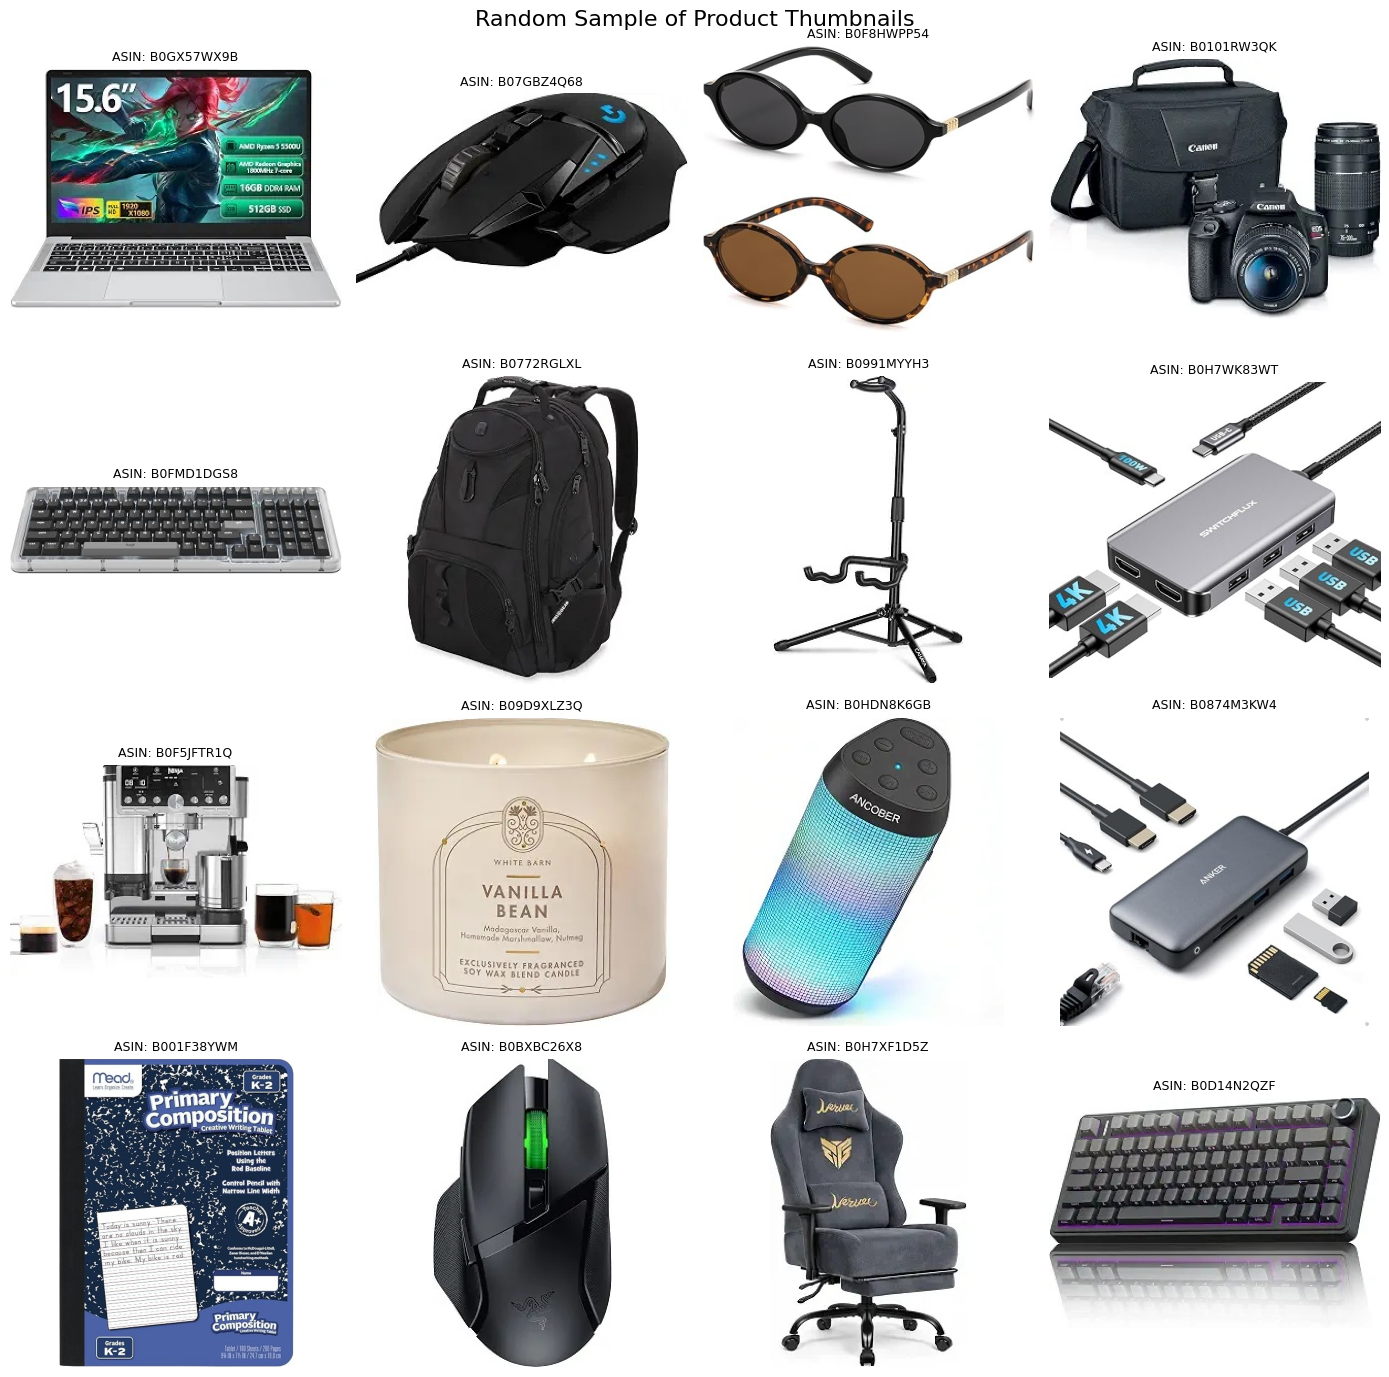

VISUAL SAMPLE INSPECTION COMPLETE
Images displayed: 16
Sampling is random and reproducible using random_state=42.

Purpose:
- Confirm downloaded images represent product thumbnails.
- Observe visual diversity before embedding and clustering.
- No product metadata is used to select the visual groups.


In [11]:
# =============================================================================
# CELL 11 — VISUAL SAMPLE INSPECTION
# =============================================================================

import math

SAMPLE_SIZE = 16

sample_images = valid_images.sample(
    n=min(SAMPLE_SIZE, len(valid_images)),
    random_state=RANDOM_STATE
).reset_index(drop=True)


fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for ax, (_, row) in zip(axes.flat, sample_images.iterrows()):

    image_path = Path(row["local_image_path"])

    try:
        image = Image.open(image_path).convert("RGB")

        ax.imshow(image)
        ax.set_title(
            f"ASIN: {row['asin']}",
            fontsize=9
        )
        ax.axis("off")

    except Exception as e:
        ax.text(
            0.5,
            0.5,
            "Image unavailable",
            ha="center",
            va="center"
        )
        ax.axis("off")


plt.suptitle(
    "Random Sample of Product Thumbnails",
    fontsize=16
)

plt.tight_layout()
plt.show()


print("=" * 80)
print("VISUAL SAMPLE INSPECTION COMPLETE")
print("=" * 80)

print(f"Images displayed: {len(sample_images)}")
print("Sampling is random and reproducible using random_state=42.")
print()
print("Purpose:")
print("- Confirm downloaded images represent product thumbnails.")
print("- Observe visual diversity before embedding and clustering.")
print("- No product metadata is used to select the visual groups.")

In [12]:
# =============================================================================
# CELL 12 — SAVE FINAL CLEAN IMAGE MANIFEST
# =============================================================================

FINAL_MANIFEST_PATH = (
    MANIFEST_DIR / "image_manifest_final.csv"
)

# ---------------------------------------------------------------------------
# KEEP ONLY VALID IMAGES
# ---------------------------------------------------------------------------

final_manifest = valid_images[
    [
        "asin",
        "image_url",
        "filename",
        "local_image_path",
        "image_width",
        "image_height",
        "aspect_ratio",
        "file_size_mb",
    ]
].copy()


# ---------------------------------------------------------------------------
# FINAL VALIDATION
# ---------------------------------------------------------------------------

assert final_manifest["asin"].notna().all()
assert final_manifest["image_url"].notna().all()
assert final_manifest["local_image_path"].notna().all()

assert final_manifest["asin"].is_unique
assert len(final_manifest) == 946

# Confirm every local image exists
missing_files = [
    path for path in final_manifest["local_image_path"]
    if not Path(path).exists()
]

assert len(missing_files) == 0, (
    f"{len(missing_files)} image files are missing."
)


# ---------------------------------------------------------------------------
# SAVE
# ---------------------------------------------------------------------------

final_manifest.to_csv(
    FINAL_MANIFEST_PATH,
    index=False
)


# ---------------------------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------------------------

print("=" * 80)
print("FINAL FEATURE C IMAGE MANIFEST")
print("=" * 80)

print(f"Total products       : {len(final_manifest):,}")
print(f"Unique ASINs         : {final_manifest['asin'].nunique():,}")
print(f"Valid image files    : {len(final_manifest):,}")
print(f"Missing image files  : {len(missing_files):,}")
print(f"Manifest columns     : {len(final_manifest.columns)}")

print("\nFinal columns:")
print(final_manifest.columns.tolist())

print("\nSaved to:")
print(FINAL_MANIFEST_PATH)

print("\n" + "=" * 80)
print("FEATURE C NOTEBOOK 1 COMPLETE")
print("=" * 80)

FINAL FEATURE C IMAGE MANIFEST
Total products       : 946
Unique ASINs         : 946
Valid image files    : 946
Missing image files  : 0
Manifest columns     : 8

Final columns:
['asin', 'image_url', 'filename', 'local_image_path', 'image_width', 'image_height', 'aspect_ratio', 'file_size_mb']

Saved to:
/content/data/processed/feature_c/manifests/image_manifest_final.csv

FEATURE C NOTEBOOK 1 COMPLETE


In [13]:
# =============================================================================
# CELL 13 — PACKAGE FEATURE C ARTIFACTS FOR VS CODE TRANSFER
# =============================================================================

import shutil
from pathlib import Path


# ---------------------------------------------------------------------------
# TRANSFER DIRECTORY
# ---------------------------------------------------------------------------

TRANSFER_DIR = FEATURE_C_DATA_DIR / "transfer"

TRANSFER_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------------------------
# CREATE TEMPORARY PACKAGE STRUCTURE
# ---------------------------------------------------------------------------

PACKAGE_DIR = TRANSFER_DIR / "feature_c_notebook_1_artifacts"

PACKAGE_IMAGES_DIR = PACKAGE_DIR / "images"
PACKAGE_MANIFEST_DIR = PACKAGE_DIR / "manifests"

PACKAGE_IMAGES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PACKAGE_MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------------------------
# COPY VALIDATED IMAGES
# ---------------------------------------------------------------------------

image_files = list(IMAGE_DIR.glob("*.jpg"))

print("=" * 80)
print("PACKAGING FEATURE C ARTIFACTS")
print("=" * 80)

print(f"Images found: {len(image_files):,}")

if len(image_files) != 946:
    raise ValueError(
        f"Expected 946 images, but found {len(image_files)}."
    )


for image_file in image_files:
    shutil.copy2(
        image_file,
        PACKAGE_IMAGES_DIR / image_file.name
    )


# ---------------------------------------------------------------------------
# COPY FINAL MANIFEST
# ---------------------------------------------------------------------------

FINAL_MANIFEST_PATH = (
    MANIFEST_DIR / "image_manifest_final.csv"
)

if not FINAL_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Final manifest not found:\n{FINAL_MANIFEST_PATH}"
    )

shutil.copy2(
    FINAL_MANIFEST_PATH,
    PACKAGE_MANIFEST_DIR / "image_manifest_final.csv"
)


# ---------------------------------------------------------------------------
# CREATE ZIP
# ---------------------------------------------------------------------------

ZIP_BASE_NAME = TRANSFER_DIR / "feature_c_notebook_1_artifacts"

zip_path = shutil.make_archive(
    base_name=str(ZIP_BASE_NAME),
    format="zip",
    root_dir=str(PACKAGE_DIR)
)

zip_path = Path(zip_path)


# ---------------------------------------------------------------------------
# VERIFY PACKAGE
# ---------------------------------------------------------------------------

package_size_mb = (
    zip_path.stat().st_size / (1024 ** 2)
)

print("\n" + "=" * 80)
print("FEATURE C TRANSFER PACKAGE CREATED")
print("=" * 80)

print(f"Images packaged : {len(image_files):,}")
print("Manifest        : image_manifest_final.csv")
print(f"ZIP file        : {zip_path}")
print(f"ZIP size        : {package_size_mb:.2f} MB")

print("\nPackage contents:")
print("  images/       -> 946 JPEG product thumbnails")
print("  manifests/   -> image_manifest_final.csv")

print("\nReady for download.")

PACKAGING FEATURE C ARTIFACTS
Images found: 946

FEATURE C TRANSFER PACKAGE CREATED
Images packaged : 946
Manifest        : image_manifest_final.csv
ZIP file        : /content/data/processed/feature_c/transfer/feature_c_notebook_1_artifacts.zip
ZIP size        : 39.90 MB

Package contents:
  images/       -> 946 JPEG product thumbnails
  manifests/   -> image_manifest_final.csv

Ready for download.


In [14]:
# =============================================================================
# CELL 14 — DOWNLOAD FEATURE C TRANSFER PACKAGE
# =============================================================================

from google.colab import files

files.download(str(zip_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>